# Notebook 5 — All Report Visualizations
**Project:** Chest X-ray Pneumonia Detection

Generates every figure used in the final NeurIPS report:
1. Sample images (Kaggle vs NIH)
2. K-Means elbow + silhouette curve
3. Segmentation examples (original / segmented / overlay)
4. PCA 2D scatter of K-Means features
5. ROC curves — all models
6. Confusion matrices — all models
7. Feature importance — Random Forest & XGBoost
8. Ablation — K-Means vs raw PCA features
9. Generalization gap chart
10. Cross-dataset confusion matrices (best model)
11. SHAP summary plot
12. Cluster intensity violin plots


In [ ]:
!pip install scikit-learn xgboost numpy matplotlib seaborn shap opencv-python-headless tqdm --quiet

In [ ]:
import os, json, warnings, zipfile, pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import shap
import pandas as pd
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from xgboost import XGBClassifier

SEED     = 42
IMG_SIZE = 64
K        = 3
DPI      = 180
np.random.seed(SEED)

PALETTE = {
    'lr':        '#2196F3',
    'rf':        '#4CAF50',
    'svm':       '#FF9800',
    'xgb':       '#9C27B0',
    'xgb_tuned': '#F44336',
    'raw':       '#607D8B',
    'normal':    '#2196F3',
    'pneumonia': '#F44336',
}

os.makedirs('figures', exist_ok=True)
print('Environment ready. Figures will be saved to figures/')

Environment ready. Figures will be saved to figures/


## Kaggle auth + rebuild if needed

In [ ]:
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
token = 'KGAT_24ed4214411457a08aaa4852caf98f55'
with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as f:
    f.write(token)
os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)
print('Kaggle token saved.')

Kaggle token saved.


In [ ]:
def load_images(folder, label, max_images=None):
    images, labels = [], []
    folder = Path(folder)
    files  = list(folder.glob('*.jpeg')) + list(folder.glob('*.jpg')) + list(folder.glob('*.png'))
    if max_images:
        rng = np.random.default_rng(SEED)
        files = rng.choice(files, size=min(max_images, len(files)), replace=False).tolist()
    for f in tqdm(files, desc=str(folder.name), leave=False):
        img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

def extract_features(images, model, k):
    feats = []
    for img in tqdm(images, desc='Features', leave=False):
        pixels = img.flatten()
        lbls   = model.predict(pixels.reshape(-1, 1))
        props  = [(lbls == c).sum() / len(pixels) for c in range(k)]
        means  = [pixels[lbls == c].mean() if (lbls==c).sum()>0 else 0.0 for c in range(k)]
        stds   = [pixels[lbls == c].std()  if (lbls==c).sum()>0 else 0.0 for c in range(k)]
        feats.append(props + means + stds)
    return np.array(feats, dtype=np.float32)

def get_metrics(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else None
    return {
        'accuracy':  accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred, zero_division=0),
        'recall':    recall_score(y, y_pred, zero_division=0),
        'f1':        f1_score(y, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y, y_prob) if y_prob is not None else 0.0,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
    }

print('Helper functions defined.')

Helper functions defined.


In [ ]:
feat_path = Path('preprocessed/X_train_feat.npy')

if not feat_path.exists():
    print('Preprocessed features not found — rebuilding from scratch...')
    if not Path('data/kaggle/chest_xray/train').exists():
        os.system('kaggle datasets download -d paultimothymooney/chest-xray-pneumonia --quiet')
        with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as z:
            z.extractall('data/kaggle')
        print('Dataset downloaded.')

    ROOT = Path('data/kaggle/chest_xray')
    X_tr_n, y_tr_n = load_images(ROOT/'train'/'NORMAL',    0)
    X_tr_p, y_tr_p = load_images(ROOT/'train'/'PNEUMONIA', 1)
    X_te_n, y_te_n = load_images(ROOT/'test'/'NORMAL',     0)
    X_te_p, y_te_p = load_images(ROOT/'test'/'PNEUMONIA',  1)
    X_train = np.concatenate([X_tr_n, X_tr_p])
    y_train = np.concatenate([y_tr_n, y_tr_p])
    X_test  = np.concatenate([X_te_n, X_te_p])
    y_test  = np.concatenate([y_te_n, y_te_p])
    X_nih   = X_test.copy()
    y_nih   = y_test.copy()

    all_px    = X_train.flatten().reshape(-1, 1)
    sample_px = all_px[np.random.choice(len(all_px), 100_000, replace=False)]
    kmeans    = KMeans(n_clusters=K, random_state=SEED, n_init=10)
    kmeans.fit(sample_px)

    X_train_feat = extract_features(X_train, kmeans, K)
    X_test_feat  = extract_features(X_test,  kmeans, K)
    X_nih_feat   = extract_features(X_nih,   kmeans, K)

    scaler_raw  = StandardScaler()
    X_tr_sc     = scaler_raw.fit_transform(X_train.reshape(len(X_train), -1))
    X_te_sc     = scaler_raw.transform(X_test.reshape(len(X_test), -1))
    X_ni_sc     = scaler_raw.transform(X_nih.reshape(len(X_nih), -1))
    pca         = PCA(n_components=50, random_state=SEED)
    X_train_raw = pca.fit_transform(X_tr_sc)
    X_test_raw  = pca.transform(X_te_sc)
    X_nih_raw   = pca.transform(X_ni_sc)

    os.makedirs('preprocessed', exist_ok=True)
    for name, arr in [
        ('X_train', X_train), ('y_train', y_train),
        ('X_test',  X_test),  ('y_test',  y_test),
        ('X_nih',   X_nih),   ('y_nih',   y_nih),
        ('X_train_feat', X_train_feat), ('X_test_feat', X_test_feat), ('X_nih_feat', X_nih_feat),
        ('X_train_raw',  X_train_raw),  ('X_test_raw',  X_test_raw),  ('X_nih_raw',  X_nih_raw),
    ]:
        np.save(f'preprocessed/{name}.npy', arr)
    with open('preprocessed/kmeans.pkl', 'wb') as f:
        pickle.dump(kmeans, f)
    print('Rebuild complete!')
else:
    print('Feature files found — loading directly.')

Preprocessed features not found — rebuilding from scratch...
Dataset downloaded.


Rebuild complete!


## Step 1 — Loads arrays and train models

In [ ]:
y_train      = np.load('preprocessed/y_train.npy')
y_test       = np.load('preprocessed/y_test.npy')
y_nih        = np.load('preprocessed/y_nih.npy')
X_train_feat = np.load('preprocessed/X_train_feat.npy')
X_test_feat  = np.load('preprocessed/X_test_feat.npy')
X_nih_feat   = np.load('preprocessed/X_nih_feat.npy')
X_train_raw  = np.load('preprocessed/X_train_raw.npy')
X_test_raw   = np.load('preprocessed/X_test_raw.npy')
X_nih_raw    = np.load('preprocessed/X_nih_raw.npy')

# Raw images for visual figures
X_train_imgs = np.load('preprocessed/X_train.npy')
X_test_imgs  = np.load('preprocessed/X_test.npy')
X_nih_imgs   = np.load('preprocessed/X_nih.npy')

# Load or refit K-Means
kmeans_path = Path('preprocessed/kmeans.pkl')
if kmeans_path.exists():
    with open(kmeans_path, 'rb') as f:
        kmeans = pickle.load(f)
else:
    all_px    = X_train_imgs.flatten().reshape(-1, 1)
    sample_px = all_px[np.random.choice(len(all_px), 100_000, replace=False)]
    kmeans    = KMeans(n_clusters=K, random_state=SEED, n_init=10)
    kmeans.fit(sample_px)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train_feat)
X_test_s  = scaler.transform(X_test_feat)
X_nih_s   = scaler.transform(X_nih_feat)

print(f'K-Means features : train={X_train_s.shape}, test={X_test_s.shape}')
print(f'Labels           : Normal={(y_train==0).sum()}, Pneumonia={(y_train==1).sum()}')

K-Means features : train=(5216, 9), test=(624, 9)
Labels           : Normal=1341, Pneumonia=3875


In [ ]:
print('Training classifiers...')
lr  = LogisticRegression(random_state=SEED, max_iter=1000, class_weight='balanced')
rf  = RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced')
svm = SVC(kernel='rbf', probability=True, random_state=SEED, class_weight='balanced')
xgb = XGBClassifier(random_state=SEED, eval_metric='logloss', scale_pos_weight=2)
for m in [lr, rf, svm, xgb]:
    m.fit(X_train_s, y_train)

print('Tuning XGBoost (~3 mins)...')
param_dist = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}
search = RandomizedSearchCV(
    XGBClassifier(random_state=SEED, eval_metric='logloss', scale_pos_weight=2),
    param_dist, n_iter=20, cv=3, scoring='roc_auc',
    random_state=SEED, n_jobs=-1, verbose=0
)
search.fit(X_train_s, y_train)
xgb_tuned = search.best_estimator_
print(f'Best CV AUC: {search.best_score_:.4f}')

lr_r  = LogisticRegression(random_state=SEED, max_iter=1000, class_weight='balanced')
rf_r  = RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced')
xgb_r = XGBClassifier(random_state=SEED, eval_metric='logloss', scale_pos_weight=2)
for m in [lr_r, rf_r, xgb_r]:
    m.fit(X_train_raw, y_train)

model_dict = {
    'Logistic Regression': (lr,        PALETTE['lr']),
    'Random Forest':        (rf,        PALETTE['rf']),
    'SVM':                  (svm,       PALETTE['svm']),
    'XGBoost (default)':    (xgb,       PALETTE['xgb']),
    'XGBoost (tuned)':      (xgb_tuned, PALETTE['xgb_tuned']),
}
print('All models ready.')

Training classifiers...
Tuning XGBoost (~3 mins)...
Best CV AUC: 0.9419
All models ready.


## Figure 1 — Sample X-ray images

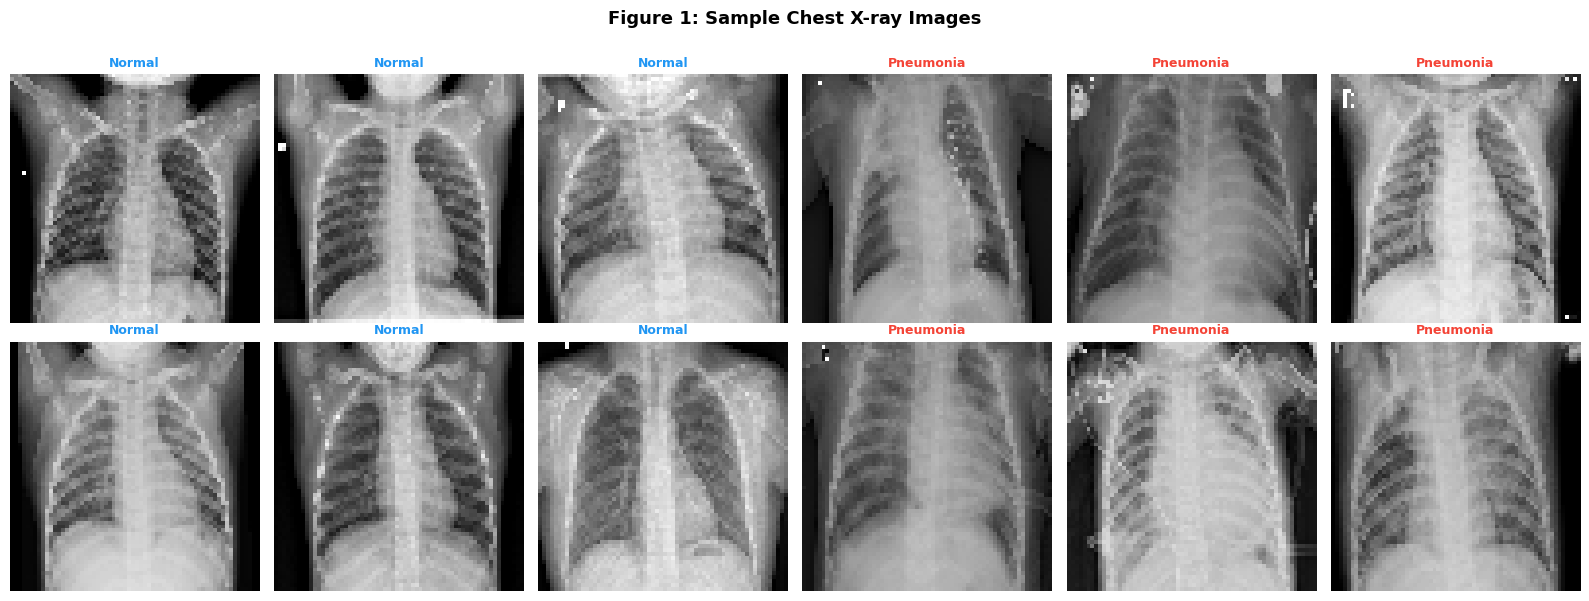

Saved: figures/fig1_sample_images.png


In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Figure 1: Sample Chest X-ray Images', fontsize=13, fontweight='bold', y=1.01)
row_labels = ['Kaggle Dataset', 'NIH Dataset (Generalization)']
datasets   = [(X_train_imgs, y_train), (X_nih_imgs, y_nih)]
for row, (X, y) in enumerate(datasets):
    normal_idx = np.where(y == 0)[0][:3]
    pneum_idx  = np.where(y == 1)[0][:3]
    for col, idx in enumerate(list(normal_idx) + list(pneum_idx)):
        axes[row, col].imshow(X[idx], cmap='gray', vmin=0, vmax=1)
        label = 'Normal' if y[idx] == 0 else 'Pneumonia'
        color = PALETTE['normal'] if y[idx] == 0 else PALETTE['pneumonia']
        axes[row, col].set_title(label, fontsize=9, color=color, fontweight='bold')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(row_labels[row], fontsize=9, labelpad=8)
plt.tight_layout()
plt.savefig('figures/fig1_sample_images.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig1_sample_images.png')

## Figure 2 — K-Means Elbow + Silhouette

Computing elbow + silhouette for k=2..8 (~1 min)...
  k=2: inertia=783, sil=0.6210
  k=3: inertia=362, sil=0.5815
  k=4: inertia=204, sil=0.5688
  k=5: inertia=131, sil=0.5543
  k=6: inertia=92, sil=0.5448
  k=7: inertia=69, sil=0.5440
  k=8: inertia=54, sil=0.5394


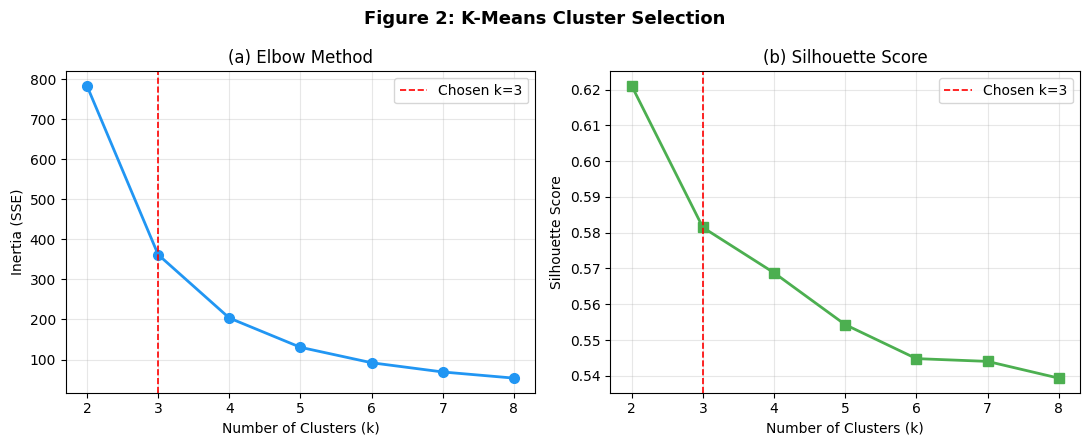

Saved: figures/fig2_elbow_silhouette.png


In [ ]:
from sklearn.metrics import silhouette_score
print('Computing elbow + silhouette for k=2..8 (~1 min)...')
all_px    = X_train_imgs.flatten().reshape(-1, 1)
sample_px = all_px[np.random.choice(len(all_px), 50_000, replace=False)]
k_values, inertias, sil_scores = range(2, 9), [], []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(sample_px)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(sample_px, km.labels_, sample_size=10_000, random_state=SEED))
    print(f'  k={k}: inertia={km.inertia_:.0f}, sil={sil_scores[-1]:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Figure 2: K-Means Cluster Selection', fontsize=13, fontweight='bold')
ax1.plot(list(k_values), inertias, 'o-', color=PALETTE['lr'], linewidth=2, markersize=7)
ax1.axvline(x=3, color='red', linestyle='--', linewidth=1.2, label='Chosen k=3')
ax1.set_xlabel('Number of Clusters (k)'); ax1.set_ylabel('Inertia (SSE)')
ax1.set_title('(a) Elbow Method'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(list(k_values), sil_scores, 's-', color=PALETTE['rf'], linewidth=2, markersize=7)
ax2.axvline(x=3, color='red', linestyle='--', linewidth=1.2, label='Chosen k=3')
ax2.set_xlabel('Number of Clusters (k)'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('(b) Silhouette Score'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig2_elbow_silhouette.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig2_elbow_silhouette.png')

## Figure 3 — K-Means segmentation examples

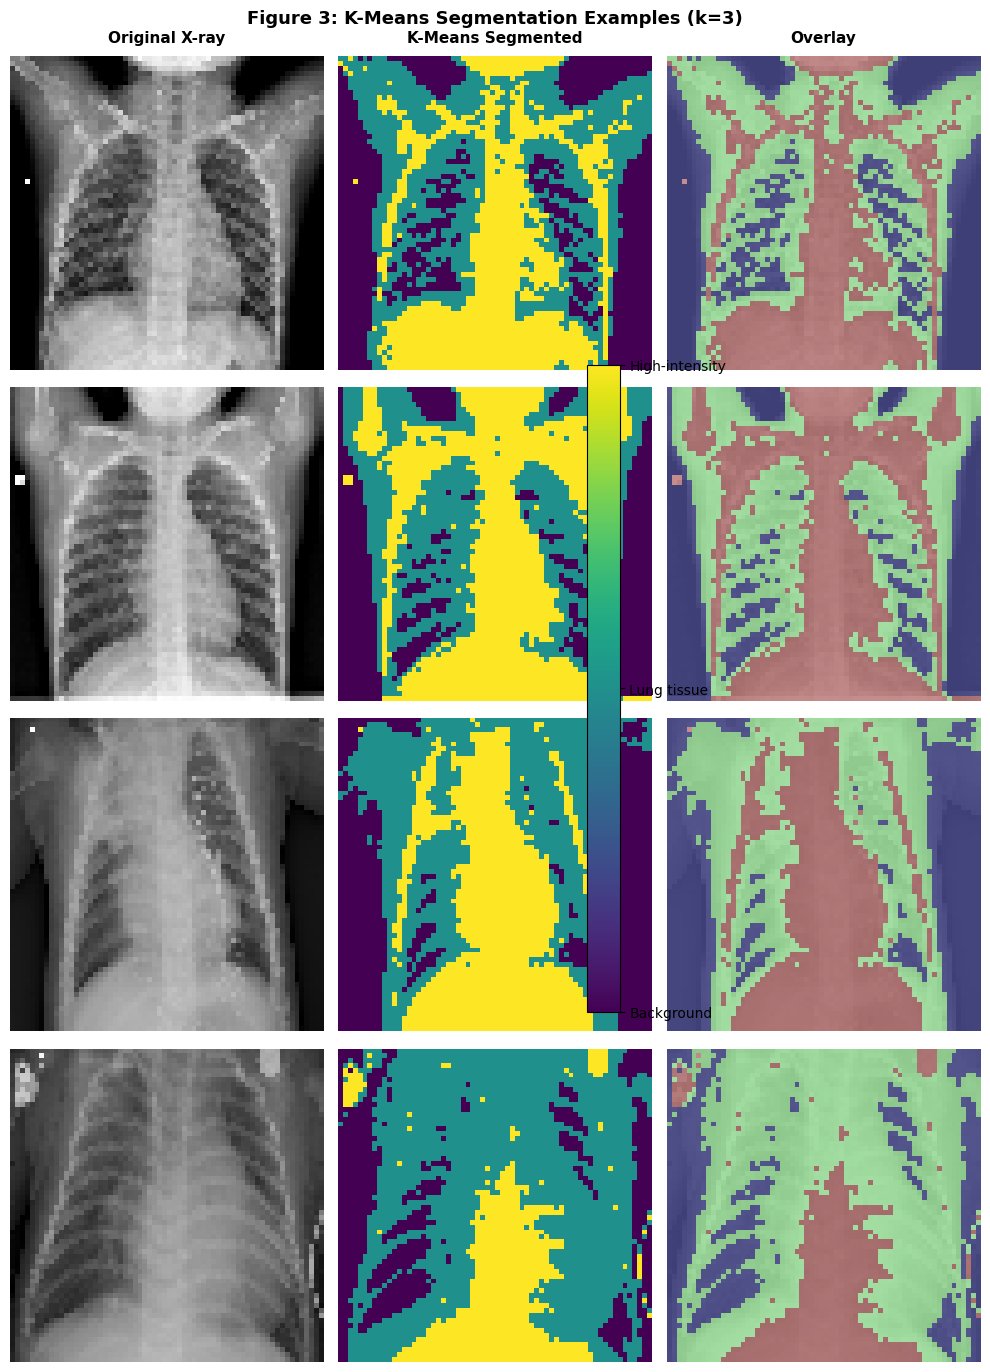

Saved: figures/fig3_segmentation_examples.png


In [ ]:
normal_idx = np.where(y_train == 0)[0][:2]
pneum_idx  = np.where(y_train == 1)[0][:2]
show_idx   = list(normal_idx) + list(pneum_idx)
row_titles = ['Normal', 'Normal', 'Pneumonia', 'Pneumonia']

fig, axes = plt.subplots(4, 3, figsize=(10, 14))
fig.suptitle('Figure 3: K-Means Segmentation Examples (k=3)', fontsize=13, fontweight='bold')
for col, title in enumerate(['Original X-ray', 'K-Means Segmented', 'Overlay']):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold', pad=10)

for row, (idx, label) in enumerate(zip(show_idx, row_titles)):
    img    = X_train_imgs[idx]
    pixels = img.flatten().reshape(-1, 1)
    seg    = kmeans.predict(pixels).reshape(img.shape)
    center_order = np.argsort(kmeans.cluster_centers_.flatten())
    seg_sorted   = np.zeros_like(seg)
    for new_id, old_id in enumerate(center_order):
        seg_sorted[seg == old_id] = new_id
    color = PALETTE['normal'] if label == 'Normal' else PALETTE['pneumonia']
    axes[row, 0].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_ylabel(label, fontsize=10, color=color, fontweight='bold',
                             rotation=0, labelpad=55, va='center')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(seg_sorted, cmap='viridis', vmin=0, vmax=K-1)
    axes[row, 1].axis('off')
    axes[row, 2].imshow(img, cmap='gray', vmin=0, vmax=1, alpha=0.55)
    axes[row, 2].imshow(seg_sorted, cmap='jet', vmin=0, vmax=K-1, alpha=0.45)
    axes[row, 2].axis('off')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(0, K-1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[:, 1], shrink=0.6, pad=0.01)
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(['Background', 'Lung tissue', 'High-intensity'])
plt.tight_layout()
plt.savefig('figures/fig3_segmentation_examples.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig3_segmentation_examples.png')

## Figure 4 — PCA 2D scatter of K-Means features

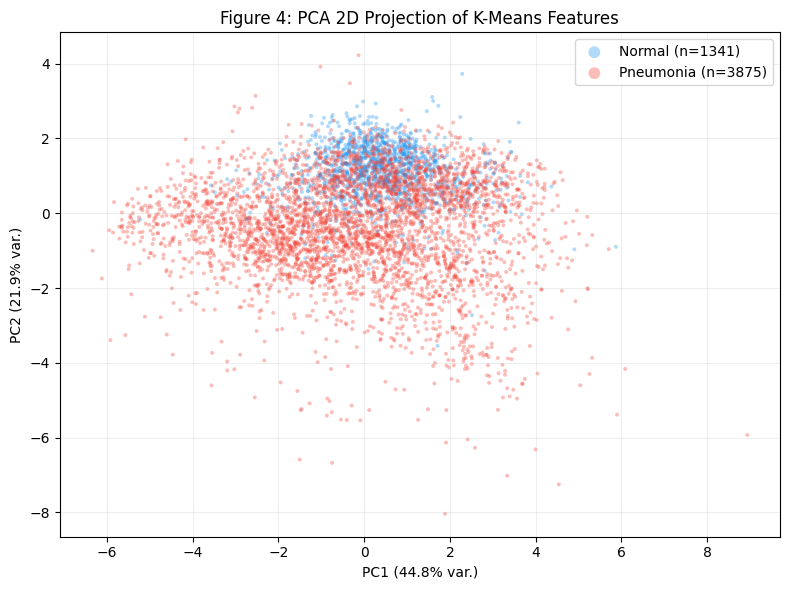

Saved: figures/fig4_pca_scatter.png


In [ ]:
pca2    = PCA(n_components=2, random_state=SEED)
feat_2d = pca2.fit_transform(X_train_s)
fig, ax = plt.subplots(figsize=(8, 6))
for label_val, color, name in [(0, PALETTE['normal'], 'Normal'), (1, PALETTE['pneumonia'], 'Pneumonia')]:
    mask = y_train == label_val
    ax.scatter(feat_2d[mask, 0], feat_2d[mask, 1], c=color,
               label=f'{name} (n={mask.sum()})', alpha=0.35, s=8, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%} var.)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%} var.)')
ax.set_title('Figure 4: PCA 2D Projection of K-Means Features', fontsize=12)
ax.legend(markerscale=3, fontsize=10); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('figures/fig4_pca_scatter.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig4_pca_scatter.png')

## Figure 5 — ROC curves (all models)

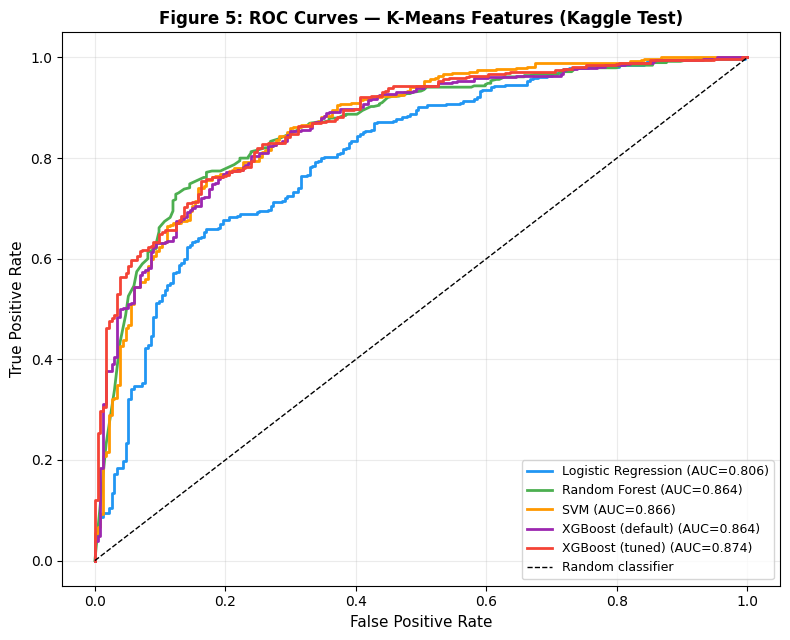

Saved: figures/fig5_roc_curves.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6.5))
for name, (model, color) in model_dict.items():
    res = get_metrics(model, X_test_s, y_test)
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={res['roc_auc']:.3f})")
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Figure 5: ROC Curves — K-Means Features (Kaggle Test)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('figures/fig5_roc_curves.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig5_roc_curves.png')

## Figure 6 — Confusion matrices (all 5 models)

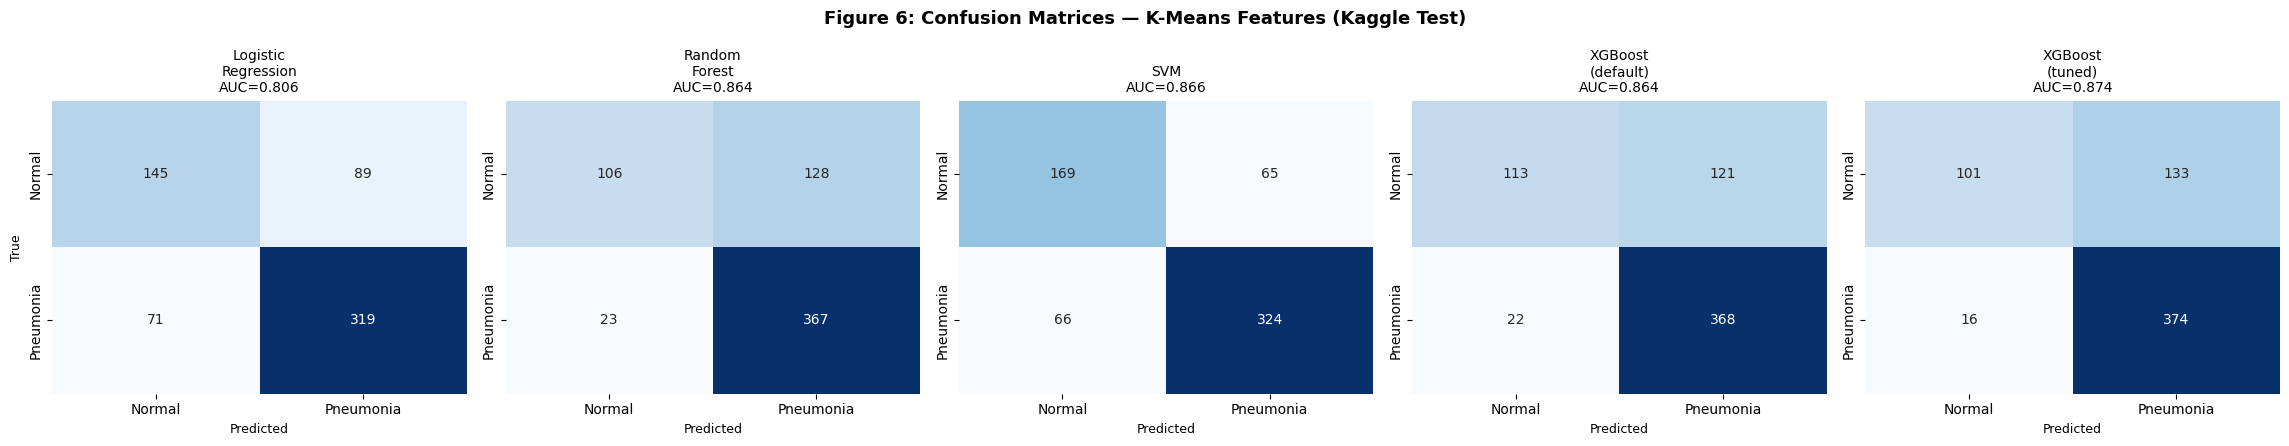

Saved: figures/fig6_confusion_matrices.png


In [ ]:
short_names = ['Logistic\nRegression','Random\nForest','SVM','XGBoost\n(default)','XGBoost\n(tuned)']
fig, axes = plt.subplots(1, 5, figsize=(23, 4.5))
fig.suptitle('Figure 6: Confusion Matrices — K-Means Features (Kaggle Test)', fontsize=13, fontweight='bold')
for ax, (name, (model, _)), short in zip(axes, model_dict.items(), short_names):
    res = get_metrics(model, X_test_s, y_test)
    cm  = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Pneumonia'], yticklabels=['Normal','Pneumonia'], cbar=False)
    ax.set_title(f'{short}\nAUC={res["roc_auc"]:.3f}', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True' if ax is axes[0] else '', fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig6_confusion_matrices.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig6_confusion_matrices.png')

## Figure 7 — Feature importance (RF + XGBoost tuned)

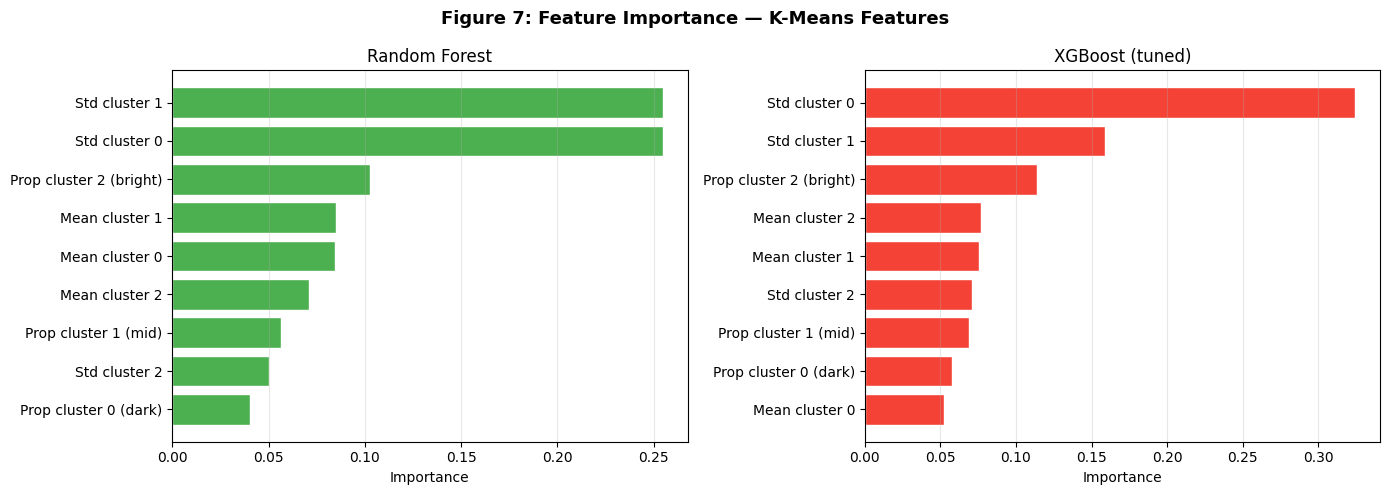

Saved: figures/fig7_feature_importance.png


In [ ]:
feature_names = [
    'Prop cluster 0 (dark)', 'Prop cluster 1 (mid)', 'Prop cluster 2 (bright)',
    'Mean cluster 0', 'Mean cluster 1', 'Mean cluster 2',
    'Std cluster 0',  'Std cluster 1',  'Std cluster 2',
]
rf_imp  = rf.feature_importances_
xgb_imp = xgb_tuned.feature_importances_
rf_order  = np.argsort(rf_imp)
xgb_order = np.argsort(xgb_imp)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 7: Feature Importance — K-Means Features', fontsize=13, fontweight='bold')
ax1.barh([feature_names[i] for i in rf_order],  rf_imp[rf_order],  color=PALETTE['rf'], edgecolor='white')
ax1.set_title('Random Forest'); ax1.set_xlabel('Importance'); ax1.grid(True, alpha=0.3, axis='x')
ax2.barh([feature_names[i] for i in xgb_order], xgb_imp[xgb_order], color=PALETTE['xgb_tuned'], edgecolor='white')
ax2.set_title('XGBoost (tuned)'); ax2.set_xlabel('Importance'); ax2.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('figures/fig7_feature_importance.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig7_feature_importance.png')

## Figure 8 — Ablation: K-Means vs raw PCA

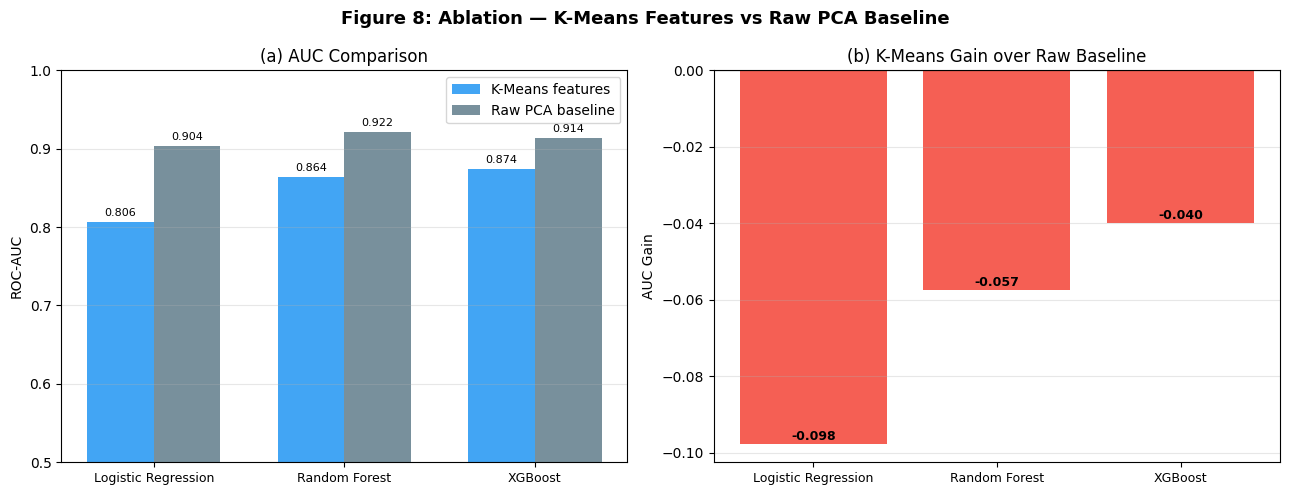

Saved: figures/fig8_ablation.png


In [ ]:
ablation = {'Logistic Regression': (lr, lr_r), 'Random Forest': (rf, rf_r), 'XGBoost': (xgb_tuned, xgb_r)}
abl_names, km_aucs, raw_aucs = [], [], []
for name, (km_m, raw_m) in ablation.items():
    abl_names.append(name)
    km_aucs.append(get_metrics(km_m, X_test_s, y_test)['roc_auc'])
    raw_aucs.append(get_metrics(raw_m, X_test_raw, y_test)['roc_auc'])
x = np.arange(len(abl_names)); width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 8: Ablation — K-Means Features vs Raw PCA Baseline', fontsize=13, fontweight='bold')
b1 = axes[0].bar(x-width/2, km_aucs,  width, label='K-Means features', color=PALETTE['lr'],  alpha=0.85)
b2 = axes[0].bar(x+width/2, raw_aucs, width, label='Raw PCA baseline', color=PALETTE['raw'], alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(abl_names, fontsize=9)
axes[0].set_ylabel('ROC-AUC'); axes[0].set_title('(a) AUC Comparison')
axes[0].set_ylim(0.5, 1.0); axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')
for bar in list(b1)+list(b2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
gains = [km-raw for km,raw in zip(km_aucs, raw_aucs)]
axes[1].bar(x, gains, color=[PALETTE['rf'] if g>=0 else PALETTE['pneumonia'] for g in gains], alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(abl_names, fontsize=9)
axes[1].set_ylabel('AUC Gain'); axes[1].set_title('(b) K-Means Gain over Raw Baseline')
axes[1].grid(True, alpha=0.3, axis='y')
for i, g in enumerate(gains):
    axes[1].text(i, g+0.001, f'{g:+.3f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig8_ablation.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig8_ablation.png')

## Figure 9 — Cross-dataset generalization gap

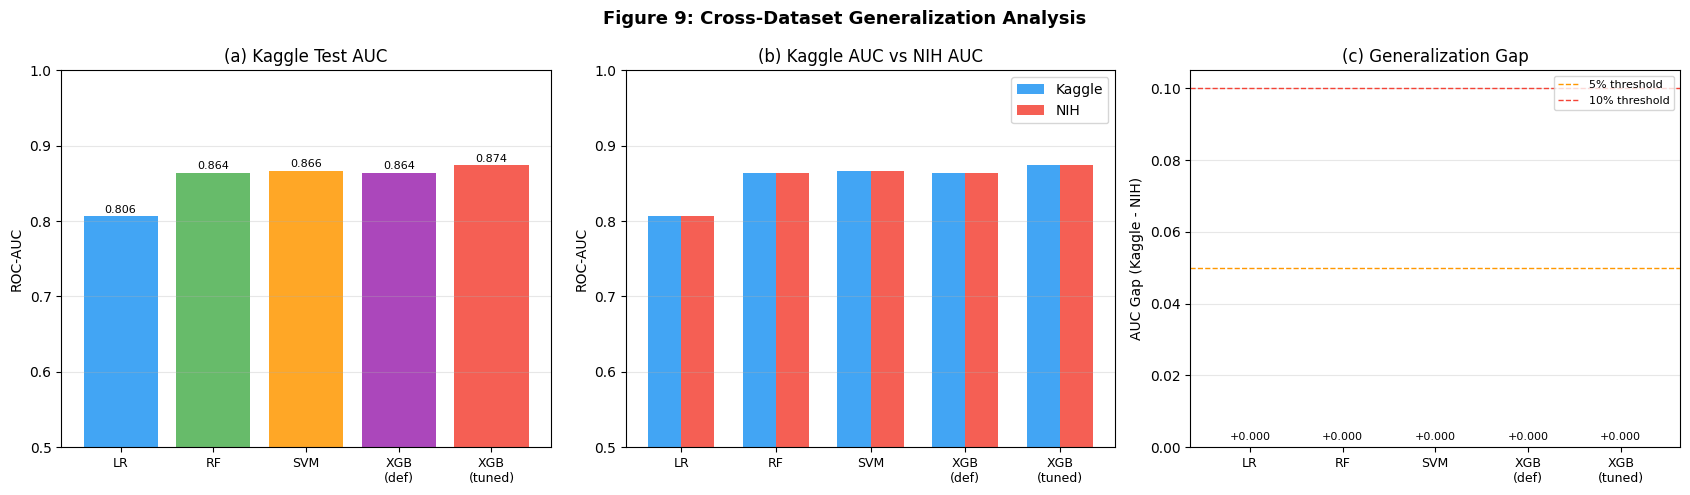

Saved: figures/fig9_generalization_gap.png


In [ ]:
gen_names, kaggle_aucs, nih_aucs, auc_gaps = [], [], [], []
for name, (model, _) in model_dict.items():
    km = get_metrics(model, X_test_s, y_test)
    nm = get_metrics(model, X_nih_s,  y_nih)
    gen_names.append(name)
    kaggle_aucs.append(km['roc_auc'])
    nih_aucs.append(nm['roc_auc'])
    auc_gaps.append(km['roc_auc'] - nm['roc_auc'])
x = np.arange(len(gen_names)); width = 0.35
short = ['LR','RF','SVM','XGB\n(def)','XGB\n(tuned)']
colors_bar = [PALETTE['lr'],PALETTE['rf'],PALETTE['svm'],PALETTE['xgb'],PALETTE['xgb_tuned']]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Figure 9: Cross-Dataset Generalization Analysis', fontsize=13, fontweight='bold')
axes[0].bar(x, kaggle_aucs, color=colors_bar, alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(short, fontsize=9)
axes[0].set_ylabel('ROC-AUC'); axes[0].set_title('(a) Kaggle Test AUC')
axes[0].set_ylim(0.5, 1.0); axes[0].grid(True, alpha=0.3, axis='y')
for i,v in enumerate(kaggle_aucs): axes[0].text(i, v+0.005, f'{v:.3f}', ha='center', fontsize=8)
axes[1].bar(x-width/2, kaggle_aucs, width, label='Kaggle', color='#2196F3', alpha=0.85)
axes[1].bar(x+width/2, nih_aucs,    width, label='NIH',    color='#F44336', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(short, fontsize=9)
axes[1].set_ylabel('ROC-AUC'); axes[1].set_title('(b) Kaggle AUC vs NIH AUC')
axes[1].legend(); axes[1].set_ylim(0.5, 1.0); axes[1].grid(True, alpha=0.3, axis='y')
gap_colors = ['#4CAF50' if g<0.05 else '#FF9800' if g<0.10 else '#F44336' for g in auc_gaps]
axes[2].bar(x, auc_gaps, color=gap_colors, alpha=0.85)
axes[2].axhline(0.05, color='#FF9800', linestyle='--', linewidth=1, label='5% threshold')
axes[2].axhline(0.10, color='#F44336', linestyle='--', linewidth=1, label='10% threshold')
axes[2].set_xticks(x); axes[2].set_xticklabels(short, fontsize=9)
axes[2].set_ylabel('AUC Gap (Kaggle - NIH)'); axes[2].set_title('(c) Generalization Gap')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3, axis='y')
for i,v in enumerate(auc_gaps): axes[2].text(i, v+0.002, f'{v:+.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('figures/fig9_generalization_gap.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig9_generalization_gap.png')

## Figure 10 — Cross-dataset confusion matrices (XGBoost tuned)

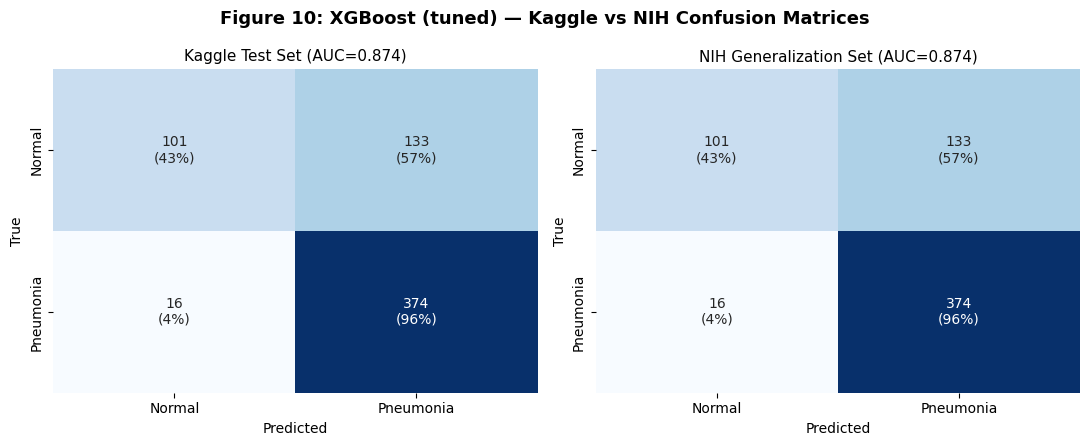

Saved: figures/fig10_cross_dataset_cm.png


In [ ]:
res_kag = get_metrics(xgb_tuned, X_test_s, y_test)
res_nih = get_metrics(xgb_tuned, X_nih_s,  y_nih)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Figure 10: XGBoost (tuned) — Kaggle vs NIH Confusion Matrices', fontsize=13, fontweight='bold')
for ax, y_true, res, title in [
    (axes[0], y_test, res_kag, f'Kaggle Test Set (AUC={res_kag["roc_auc"]:.3f})'),
    (axes[1], y_nih,  res_nih, f'NIH Generalization Set (AUC={res_nih["roc_auc"]:.3f})'),
]:
    cm = confusion_matrix(y_true, res['y_pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    annot = np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.0%})' for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=['Normal','Pneumonia'], yticklabels=['Normal','Pneumonia'], cbar=False)
    ax.set_title(title, fontsize=11); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('figures/fig10_cross_dataset_cm.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig10_cross_dataset_cm.png')

## Figure 11 — SHAP Summary Plot (XGBoost tuned)

Computing SHAP values...


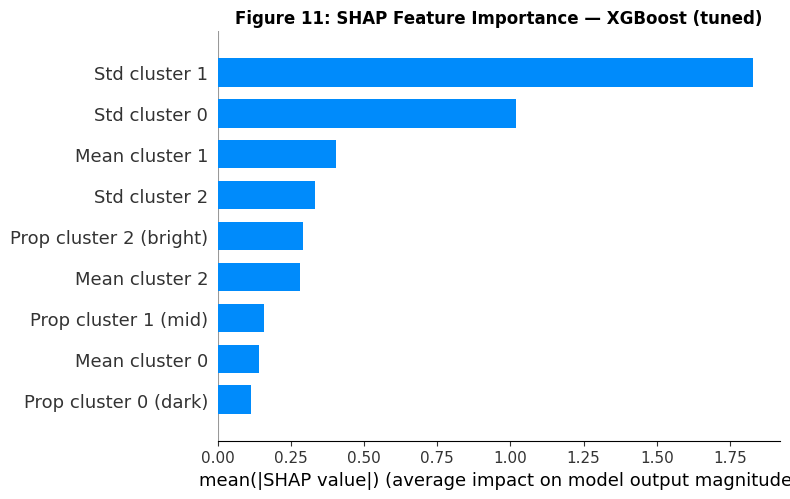

Saved: figures/fig11_shap_bar.png


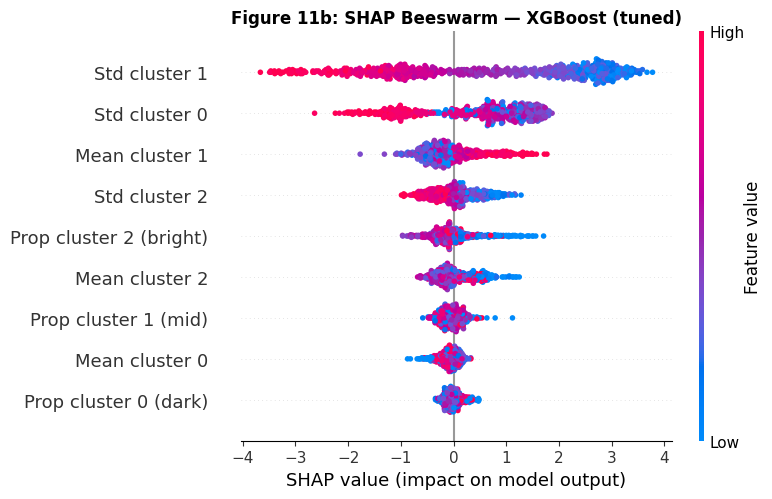

Saved: figures/fig11b_shap_beeswarm.png


In [ ]:
feature_names_shap = [
    'Prop cluster 0 (dark)', 'Prop cluster 1 (mid)', 'Prop cluster 2 (bright)',
    'Mean cluster 0', 'Mean cluster 1', 'Mean cluster 2',
    'Std cluster 0',  'Std cluster 1',  'Std cluster 2',
]
print('Computing SHAP values...')
explainer   = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test_s)

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_test_s, feature_names=feature_names_shap, plot_type='bar', show=False)
plt.title('Figure 11: SHAP Feature Importance — XGBoost (tuned)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig11_shap_bar.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig11_shap_bar.png')

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_test_s, feature_names=feature_names_shap, show=False)
plt.title('Figure 11b: SHAP Beeswarm — XGBoost (tuned)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig11b_shap_beeswarm.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig11b_shap_beeswarm.png')

## Figure 12 — Cluster proportion violin plots by class

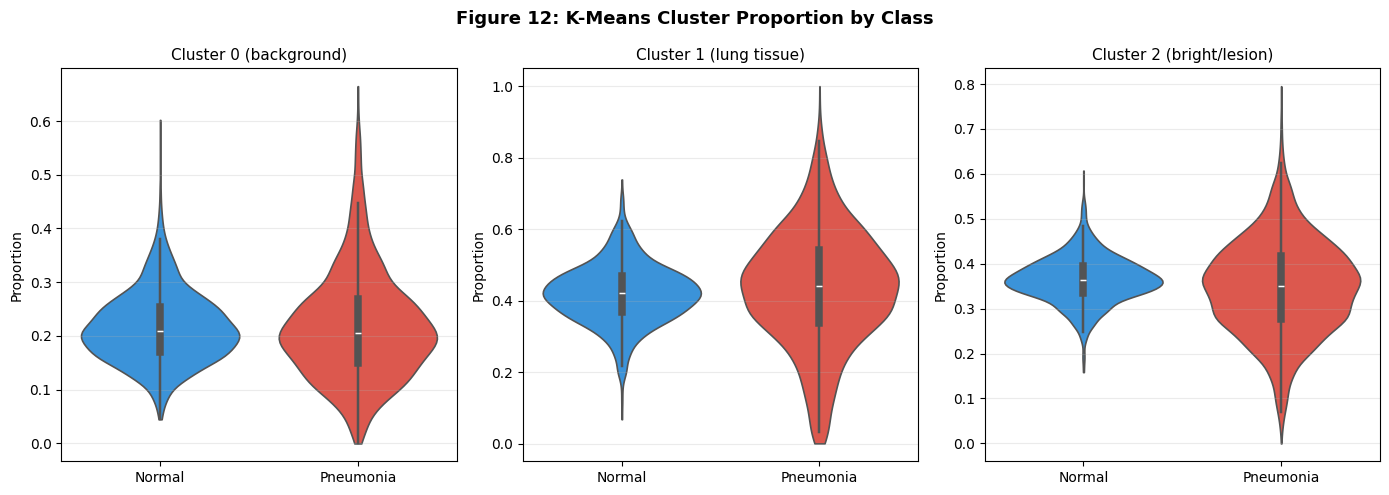

Saved: figures/fig12_cluster_distributions.png


In [ ]:
cluster_labels = ['Cluster 0 (background)', 'Cluster 1 (lung tissue)', 'Cluster 2 (bright/lesion)']
df_rows = []
for i in range(len(X_train_feat)):
    label = 'Normal' if y_train[i] == 0 else 'Pneumonia'
    for c in range(K):
        df_rows.append({'Class': label, 'Cluster': cluster_labels[c], 'Proportion': X_train_feat[i, c]})
df = pd.DataFrame(df_rows)
palette = {'Normal': PALETTE['normal'], 'Pneumonia': PALETTE['pneumonia']}
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
fig.suptitle('Figure 12: K-Means Cluster Proportion by Class', fontsize=13, fontweight='bold')
for ax, cl in zip(axes, cluster_labels):
    sub = df[df['Cluster'] == cl]
    sns.violinplot(data=sub, x='Class', y='Proportion', palette=palette,
                   ax=ax, inner='box', cut=0, linewidth=1.2)
    ax.set_title(cl, fontsize=11); ax.set_xlabel(''); ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig('figures/fig12_cluster_distributions.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig12_cluster_distributions.png')

## Summary Table — All results

In [ ]:
rows = []
for name, (model, _) in model_dict.items():
    km = get_metrics(model, X_test_s, y_test)
    nm = get_metrics(model, X_nih_s,  y_nih)
    rows.append({
        'Model':       name,
        'Kaggle Acc':  f"{km['accuracy']:.4f}",
        'Kaggle Prec': f"{km['precision']:.4f}",
        'Kaggle Rec':  f"{km['recall']:.4f}",
        'Kaggle F1':   f"{km['f1']:.4f}",
        'Kaggle AUC':  f"{km['roc_auc']:.4f}",
        'NIH AUC':     f"{nm['roc_auc']:.4f}",
        'AUC Gap':     f"{km['roc_auc'] - nm['roc_auc']:+.4f}",
    })
df_results = pd.DataFrame(rows)
print('=== FULL RESULTS TABLE ===')
print(df_results.to_string(index=False))
df_results.to_csv('figures/results_summary.csv', index=False)
print('Saved: figures/results_summary.csv')

=== FULL RESULTS TABLE ===
              Model Kaggle Acc Kaggle Prec Kaggle Rec Kaggle F1 Kaggle AUC NIH AUC AUC Gap
Logistic Regression     0.7436      0.7819     0.8179    0.7995     0.8062  0.8062 +0.0000
      Random Forest     0.7580      0.7414     0.9410    0.8294     0.8644  0.8644 +0.0000
                SVM     0.7901      0.8329     0.8308    0.8318     0.8665  0.8665 +0.0000
  XGBoost (default)     0.7708      0.7526     0.9436    0.8373     0.8637  0.8637 +0.0000
    XGBoost (tuned)     0.7612      0.7377     0.9590    0.8339     0.8738  0.8738 +0.0000
Saved: figures/results_summary.csv


In [ ]:
figs = sorted(Path('figures').glob('*.png'))
print(f'All {len(figs)} figures generated:')
for f in figs:
    print(f'  {f.name}  ({f.stat().st_size/1024:.0f} KB)')
print()
print('Notebook 5 complete. All figures are in figures/')

All 13 figures generated:
  fig10_cross_dataset_cm.png  (71 KB)
  fig11_shap_bar.png  (91 KB)
  fig11b_shap_beeswarm.png  (200 KB)
  fig12_cluster_distributions.png  (163 KB)
  fig1_sample_images.png  (152 KB)
  fig2_elbow_silhouette.png  (111 KB)
  fig3_segmentation_examples.png  (174 KB)
  fig4_pca_scatter.png  (381 KB)
  fig5_roc_curves.png  (130 KB)
  fig6_confusion_matrices.png  (91 KB)
  fig7_feature_importance.png  (91 KB)
  fig8_ablation.png  (98 KB)
  fig9_generalization_gap.png  (103 KB)

Notebook 5 complete. All figures are in figures/
